In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt



2026-01-16 16:43:04.974014: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-16 16:43:04.979932: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-16 16:43:05.041259: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-16 16:43:06.813372: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
os.chdir("..")   # Go from /notebooks to project root
print("Now cwd:", os.getcwd())

Now cwd: /home/ryu/code/DL_project


In [3]:

TRAIN_DIR = "./datasets/BT-MRI/train"
TEST_DIR = "./datasets/BT-MRI/test"


In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)


In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)


In [13]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)


Found 5712 images belonging to 4 classes.


In [15]:
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)


Found 1311 images belonging to 4 classes.


In [16]:
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)


2026-01-16 16:45:12.953480: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [17]:
# for layer in base_model.layers[:-30]:
#     layer.trainable = False
# for layer in base_model.layers[-30:]:
#     layer.trainable = True



In [18]:
for layer in base_model.layers[:-80]:
    layer.trainable = False
for layer in base_model.layers[-80:]:
    layer.trainable = True


In [19]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(4, activation="softmax")
])



In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),  # very small LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [21]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=test_gen
)


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 701s 4s/step - accuracy: 0.5072 - loss: 1.2887 - val_accuracy: 0.3295 - val_loss: 1.3873
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 719s 4s/step - accuracy: 0.5916 - loss: 1.0401 - val_accuracy: 0.5095 - val_loss: 1.3630
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 719s 4s/step - accuracy: 0.6224 - loss: 0.9159 - val_accuracy: 0.5995 - val_loss: 0.9985
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 718s 4s/step - accuracy: 0.6563 - loss: 0.8318 - val_accuracy: 0.6865 - val_loss: 0.7687
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 726s 4s/step - accuracy: 0.6852 - loss: 0.7571 - val_accuracy: 0.6697 - val_loss: 0.7733
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 764s 4s/step - accuracy: 0.6992 - loss: 0.7155 - val_accuracy: 0.6979 - val_loss: 0.7429
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 735s 4s/step - accuracy: 0.7141 - loss: 0.7076 - val_accuracy: 0.6041 - val_loss: 1.3488
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 734s 4s/step - accuracy: 0.7288 - loss: 0.6713 - val_accu

In [ ]:
model.save("./models/resnet50_v2.h5")

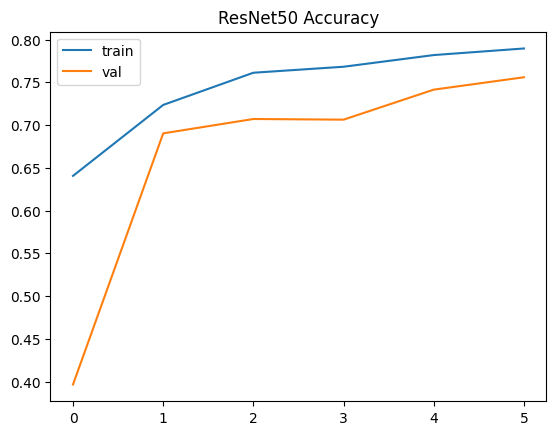

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy']) 
plt.title("ResNet50 Accuracy") 
plt.legend(["train", "val"]) 
plt.savefig("./outputs/resnet50_accuracy.png") 
plt.show()

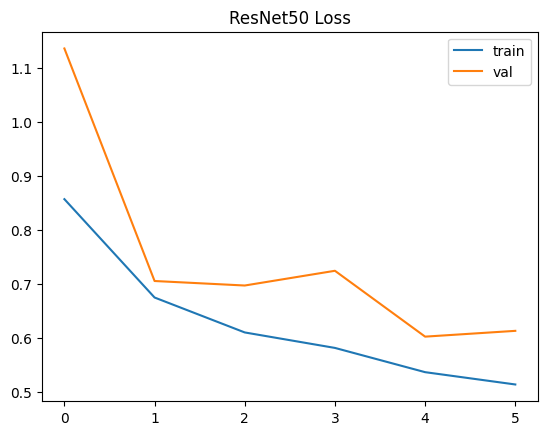

In [ ]:
plt.plot(history.history['loss']) 
plt.plot(history.history['val_loss']) 
plt.title("ResNet50 Loss") 
plt.legend(["train", "val"]) 
plt.savefig("./outputs/resnet50_loss.png") 
plt.show()